In [1]:
import argparse
import json
import os
import tempfile
import numpy as np
import subprocess
from tqdm import tqdm
import pandas as pd
import datetime
import time
import gc
import random
import sys
import shutil
import glob
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/agustin/phd/synthesis")
sys.path.append("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/experiments/utils")

# mine
import utils.nifti_functions as nfc
import utils.util as util
import utils.functions as fc
import utils.util_freesurfer_segmentation as ufs
import utils.gpu_selector as gpu_selector
import data_loaders.load_dataset as load_dataset
import utils.data_normalization as data_normalization

import prep_image as prep_image

# images
from PIL import Image




In [2]:


modalitites = ["T1W", "T2W", "T2FLAIR"]
resolutions = [0.1, 1.5, 3, 5, 7]

In [3]:
def save_2D_images(image_list, image_path_name):
    # for name_save, imgs_list in zip(name_list, list_to_save):
    imgs_list_2D = fc.cat_n_views_different_layers(
        image_list,
        view_layersoffset_list=[(2, 0), (2, -15), (1, 0), (0, 10), (0, 0)],
        axis=0,
        img_cropping=50,
        to_rgb=True,
    )
    # save synthetic images
    complete_img = np.concatenate(imgs_list_2D, axis=1)
    complete_img = Image.fromarray(complete_img)
    # complete_img.save(f"{output_path_2D_images}/imgs2D_step_{step}_subject_{batch['subject_id'][0]}.png")
    complete_img.save(image_path_name)


def prepare_images(image_list):
    imgs_list_2D = fc.cat_n_views_different_layers(
        image_list,
        view_layersoffset_list=[(2, -15), (1, 0), (0, 10)],
        axis=1,
        img_cropping=75,
        to_rgb=True,
    )
    return imgs_list_2D


In [4]:


def show_val_results(df_val, df_gt_val, output_gen_path):
    for modality in modalitites:
        for src_resolution in resolutions:
            for tar_resolution in resolutions:
                
                if src_resolution == tar_resolution:
                    continue

                if src_resolution not in [0.1, 1.5]:
                    continue

                if tar_resolution not in [7]:       
                    continue 
                src_row = df_val[(df_val["modality"] == modality) & (df_val["resolution"] == src_resolution)].iloc[0]
                sid = src_row["sid"]
                iid = src_row["iid"]
                tar_row = df_gt_val[(df_gt_val["sid"] == sid) & (df_gt_val["modality"] == modality) & (df_gt_val["resolution"] == tar_resolution)].iloc[0]
                
                src_img = nfc.load_nifti(src_row["org_img_path"])[0]
                tra_img = nfc.load_nifti(tar_row["org_img_path"])[0]
                gen_img_path = os.path.join(output_gen_path, modality, f"{src_resolution}T_to_{tar_resolution}T", "pred", f"{iid.replace(str(src_resolution), str(tar_resolution))}.nii.gz")
                gen_img = nfc.load_nifti(gen_img_path)[0]

                src_img = util.robust_normalize(src_img, (0.1, 99.9))
                gen_img = util.robust_normalize(gen_img, (0.1, 99.9))
                tra_img = util.robust_normalize(tra_img, (0.1, 99.9))

                img_2D_list = prepare_images([src_img, gen_img, tra_img])

                custom_disposition = (3,None)
                fc.imgshow_list(img_2D_list, name=f"{modality}_{src_resolution}T_to_{tar_resolution}T", custom_disposition=custom_disposition)
                plt.show()
            #     break
            # break
        # break

output_gen_path = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/evaluation/test5_segmentation_synthsr_prior/results/val/basic/merged_3/chk_280000_steps_30/with_synthsr/task3"
               
df_gt_val = pd.read_csv("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/paired_train_data.csv")
df_val = pd.read_csv("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/val_data.csv")


df_gt_val["_sid"] = df_gt_val["sid"] 
df_gt_val["sid"] = df_gt_val["iid"].apply(lambda x: f"S0{x[1:4]}")
# order by sid, modality, resolution
df_gt_val = df_gt_val.sort_values(by=["sid", "modality", "resolution"])
# display(df_gt_val.head(5))

# show_val_results(df_val, df_gt_val, output_gen_path)
    

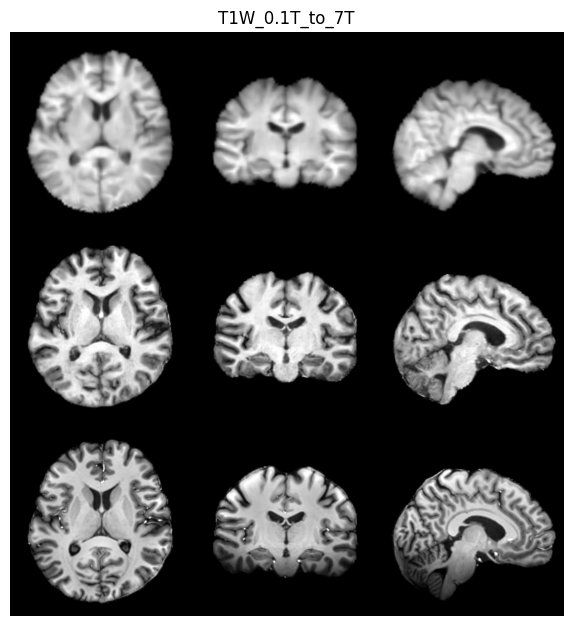

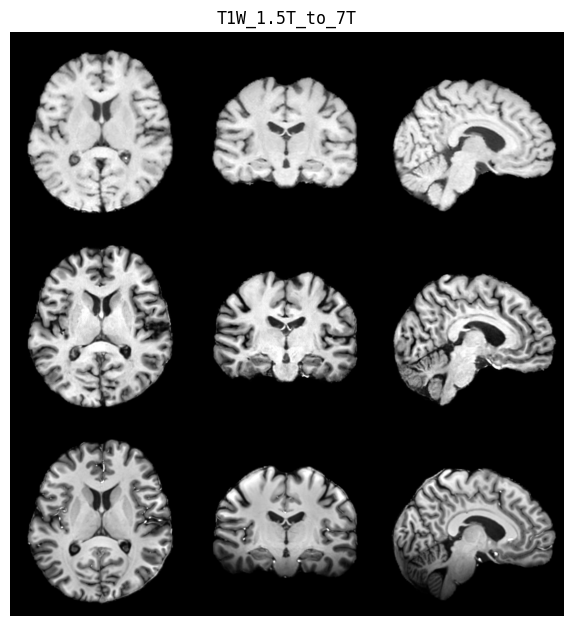

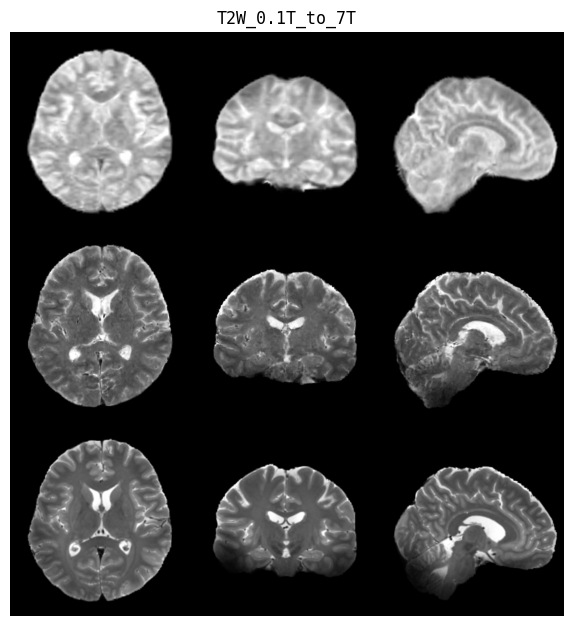

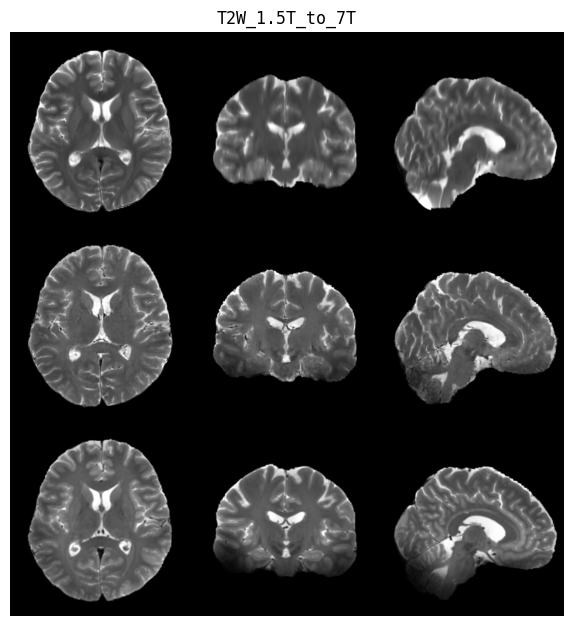

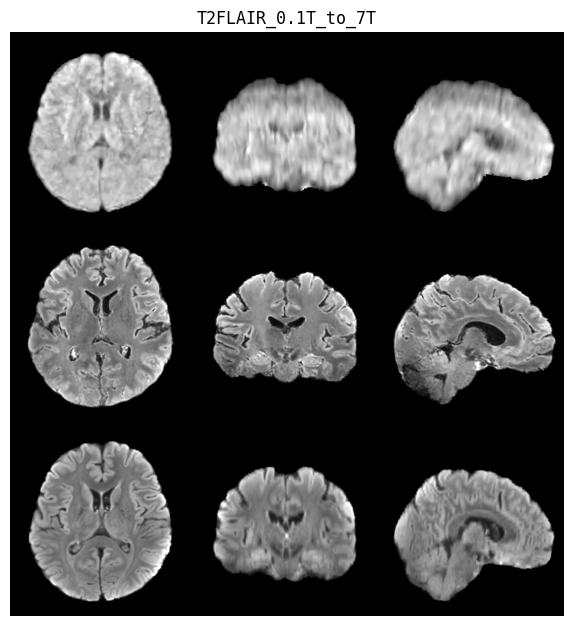

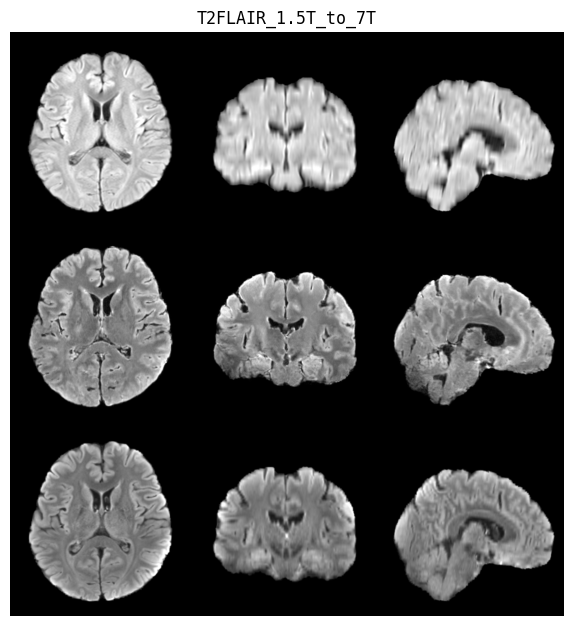

In [5]:


def show_train_results(df_train, output_gen_path):
    for modality in modalitites:
        for src_resolution in resolutions:
            for tar_resolution in resolutions:
                
                if src_resolution == tar_resolution:
                    continue

                if src_resolution not in [0.1, 1.5]:
                    continue

                if tar_resolution not in [7]:       
                    continue 
                src_row = df_train[(df_train["modality"] == modality) & (df_train["resolution"] == src_resolution)].iloc[0]
                sid = src_row["sid"]
                iid = src_row["iid"]
                tar_row = df_train[(df_train["sid"] == sid) & (df_train["modality"] == modality) & (df_train["resolution"] == tar_resolution)].iloc[0]
                
                src_img = nfc.load_nifti(src_row["org_img_path"])[0]
                tra_img = nfc.load_nifti(tar_row["org_img_path"])[0]
                gen_img_path = os.path.join(output_gen_path, modality, f"{src_resolution}T_to_{tar_resolution}T", "pred", f"{iid.replace(str(src_resolution), str(tar_resolution))}.nii.gz")
                gen_img = nfc.load_nifti(gen_img_path)[0]

                src_img = util.robust_normalize(src_img, (0.1, 99.9))
                gen_img = util.robust_normalize(gen_img, (0.1, 99.9))
                tra_img = util.robust_normalize(tra_img, (0.1, 99.9))

                img_2D_list = prepare_images([src_img, gen_img, tra_img])

                custom_disposition = (3,None)
                fc.imgshow_list(img_2D_list, name=f"{modality}_{src_resolution}T_to_{tar_resolution}T", custom_disposition=custom_disposition)
                plt.show()
            #     break
            # break
        # break

output_gen_path = "/home/agustin/phd/miccai/miccai_2026/mri_x_fields/evaluation/test5_segmentation_synthsr_prior/results/train/basic/merged_3/chk_280000_steps_30/with_synthsr/task3"
               
df_train = pd.read_csv("/home/agustin/phd/miccai/miccai_2026/mri_x_fields/data/csv/train_data.csv")
df_train = df_train[df_train["split"] == "val"]
show_train_results(df_train, output_gen_path)
    